<a href="https://colab.research.google.com/github/LukasHaussmann/2d-gaussian-splatting/blob/colab_branch/2Edgs_implementation_normal_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

In [1]:
#%cd content
!git clone -b colab_branch https://github.com/LukasHaussmann/2d-gaussian-splatting --recursive
!pip install plyfile

%cd /content/2d-gaussian-splatting/
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'
!pip install ninja
!pip install submodules/diff-surfel-rasterization
!pip install submodules/RoMa

!pip install open3d
!pip install mediapy
!pip install trimesh

# special measures to install simple-knn
# - explicitly including float.h because newer compilers reject implicit includes
%cd /content/2d-gaussian-splatting/submodules/simple-knn

# Add #include <float.h> to the top of the CUDA source file
!sed -i '1i #include <float.h>' simple_knn.cu  || sed -i '1i #include <float.h>' simple-knn.cu

# Install in editable mode
!pip install -q -e .

Cloning into '2d-gaussian-splatting'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 337 (delta 170), reused 123 (delta 104), pack-reused 79 (from 3)
Receiving objects: 100% (337/337), 9.43 MiB | 19.42 MiB/s, done.
Resolving deltas: 100% (176/176), done.
Submodule 'submodules/RoMa' (https://github.com/Parskatt/RoMa.git) registered for path 'submodules/RoMa'
Submodule 'submodules/diff-surfel-rasterization' (https://github.com/hbb1/diff-surfel-rasterization.git) registered for path 'submodules/diff-surfel-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/2d-gaussian-splatting/submodules/RoMa'...
remote: Enumerating objects: 803, done.        
remote: Counting objects: 100% (442/442), done.        
remote: Compressing objects: 100% (158/158), done.        
remote: Total 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


For Colab to access your COLMAP processed data, please copy the COLMAP output to your Google Drive and enter the full COLMAP source path (e.g. /content/drive/MyDrive/COLMAP_out)

In [5]:
%cd /content/2d-gaussian-splatting/
COLMAP_PATH = str(input('Please enter COLMAP output path:'))

/content/2d-gaussian-splatting
Please enter COLMAP output path:/content/drive/MyDrive/ADL4CV/Datasets/bicycle


**Training**

In [8]:
!python train.py -s $COLMAP_PATH --model_path output/experiment_estimated_normals --eval --iterations 5000 --densify_from_iter 500 --densify_until_iter 4500

xFormers not available
2025-12-07 09:48:07.128166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765100887.148960   11880 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765100887.155278   11880 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765100887.172116   11880 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765100887.172141   11880 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765100887.172143   11880 computation_placer.cc:177]

In [5]:
# # 1. Disable normal initialization using sed
# !sed -i 's/if pcd.normals is not None/if False and pcd.normals is not None/g' scene/gaussian_model.py
# # 2. Run Experiment 2: Random Normals
# !python train.py -s $COLMAP_PATH --model_path output/baseline_random_normals --eval --iterations 5000 --densify_from_iter 500 --densify_until_iter 4500
# # 3. Revert changes (Optional, to restore functionality)
# !sed -i 's/if False and pcd.normals is not None/if pcd.normals is not None/g' scene/gaussian_model.py

xFormers not available
2025-12-05 09:07:13.943678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764925633.963185    3398 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764925633.969126    3398 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764925633.984154    3398 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764925633.984177    3398 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764925633.984180    3398 computation_placer.cc:177]

**Mesh extraction**

In [9]:
# enter model path (found in the 'output' folder)
MODEL_PATH = str(input('Please enter model output path:'))

Please enter model output path:/content/2d-gaussian-splatting/output/experiment_estimated_normals


In [10]:
!python render.py -m {MODEL_PATH} -s $COLMAP_PATH --mesh_res 1024

xFormers not available
Looking for config file in /content/2d-gaussian-splatting/output/experiment_estimated_normals/cfg_args
Config file found: /content/2d-gaussian-splatting/output/experiment_estimated_normals/cfg_args
Rendering /content/2d-gaussian-splatting/output/experiment_estimated_normals
Loading trained model at iteration 5000
Reading camera 194/194
Loading Training Cameras
[ INFO ] Encountered quite large input images (>1.6K pixels width), rescaling to 1.6K.
 If this is not desired, please explicitly specify '--resolution/-r' as 1
Loading Test Cameras
export training images ...
reconstruct radiance fields: 169it [00:23,  7.17it/s]
The estimated bounding radius is 2.69
Use at least 5.37 for depth_trunc
export images: 169it [03:58,  1.41s/it]
export rendered testing images ...
reconstruct radiance fields: 25it [00:03,  6.44it/s]
The estimated bounding radius is 3.34
Use at least 6.67 for depth_trunc
export images: 25it [00:36,  1.48s/it]
export mesh ...
reconstruct radiance fie

In [11]:
!python metrics.py -m {MODEL_PATH}

Scene: /content/2d-gaussian-splatting/output/experiment_estimated_normals
Method: ours_5000
Metric evaluation progress:   0% 0/25 [00:00<?, ?it/s]Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth

  0% 0.00/528M [00:00<?, ?B/s]
  4% 23.6M/528M [00:00<00:02, 247MB/s]
  9% 47.2M/528M [00:00<00:02, 235MB/s]
 13% 69.8M/528M [00:00<00:02, 230MB/s]
 17% 91.8M/528M [00:00<00:02, 215MB/s]
 21% 113M/528M [00:00<00:01, 217MB/s] 
 25% 134M/528M [00:00<00:02, 205MB/s]
 29% 154M/528M [00:00<00:01, 202MB/s]
 33% 173M/528M [00:00<00:01, 197MB/s]
 37% 196M/528M [00:00<00:01, 209MB/s]
 42% 220M/528M [00:01<00:01, 223MB/s]
 46% 244M/528M [00:01<00:01, 229MB/s]
 50% 266M/528M [00:01<00:01, 216MB/s]
 54% 286M/528M [00:01<00:01, 209MB/s]
 59% 309M/528M [00:01<00:01, 216MB/s]
 63% 330M/528M [00:01<00:01, 204MB/s]
 67% 354M/528M [00:01<00:00, 216MB/s]
 72% 379M/528M [00:01<00:00, 229MB/s]
 76% 404M/528M [00:01<00:00, 238MB/s]
 81% 4

In [12]:
# save output model
!zip -r 2Edgs_bicycle_model_5k_newnormals.zip $MODEL_PATH
!mv 2Edgs_bicycle_model_5k_newnormals.zip /content/drive/MyDrive/ADL4CV/Trained_Models

  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/ (stored 0%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ (stored 0%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/ (stored 0%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/vis/ (stored 0%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/vis/depth_00149.tiff (deflated 13%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/vis/depth_00156.tiff (deflated 14%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/vis/depth_00000.tiff (deflated 14%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_5000/vis/depth_00153.tiff (deflated 15%)
  adding: content/2d-gaussian-splatting/output/experiment_estimated_normals/train/ours_500

**Comparing normal runs**

In [28]:
%cd /content/drive/MyDrive/ADL4CV/Trained_Models
!unzip 2Edgs_bicycle_model_5k_baseline_randomnormals.zip

/content/drive/MyDrive/ADL4CV/Trained_Models
Archive:  2Edgs_bicycle_model_5k_baseline_randomnormals.zip
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/
  inflating: content/2d-gaussian-splatting/output/experiment_estimated_normals/events.out.tfevents.1764852580.e6c14781b639.11436.0  
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/point_cloud/
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/point_cloud/iteration_5000/
  inflating: content/2d-gaussian-splatting/output/experiment_estimated_normals/point_cloud/iteration_5000/point_cloud.ply  
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/test/
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/test/ours_5000/
   creating: content/2d-gaussian-splatting/output/experiment_estimated_normals/test/ours_5000/vis/
  inflating: content/2d-gaussian-splatting/output/experiment_estimated_normals/t

--- Generating Comparison for View: _DSC8768 ---


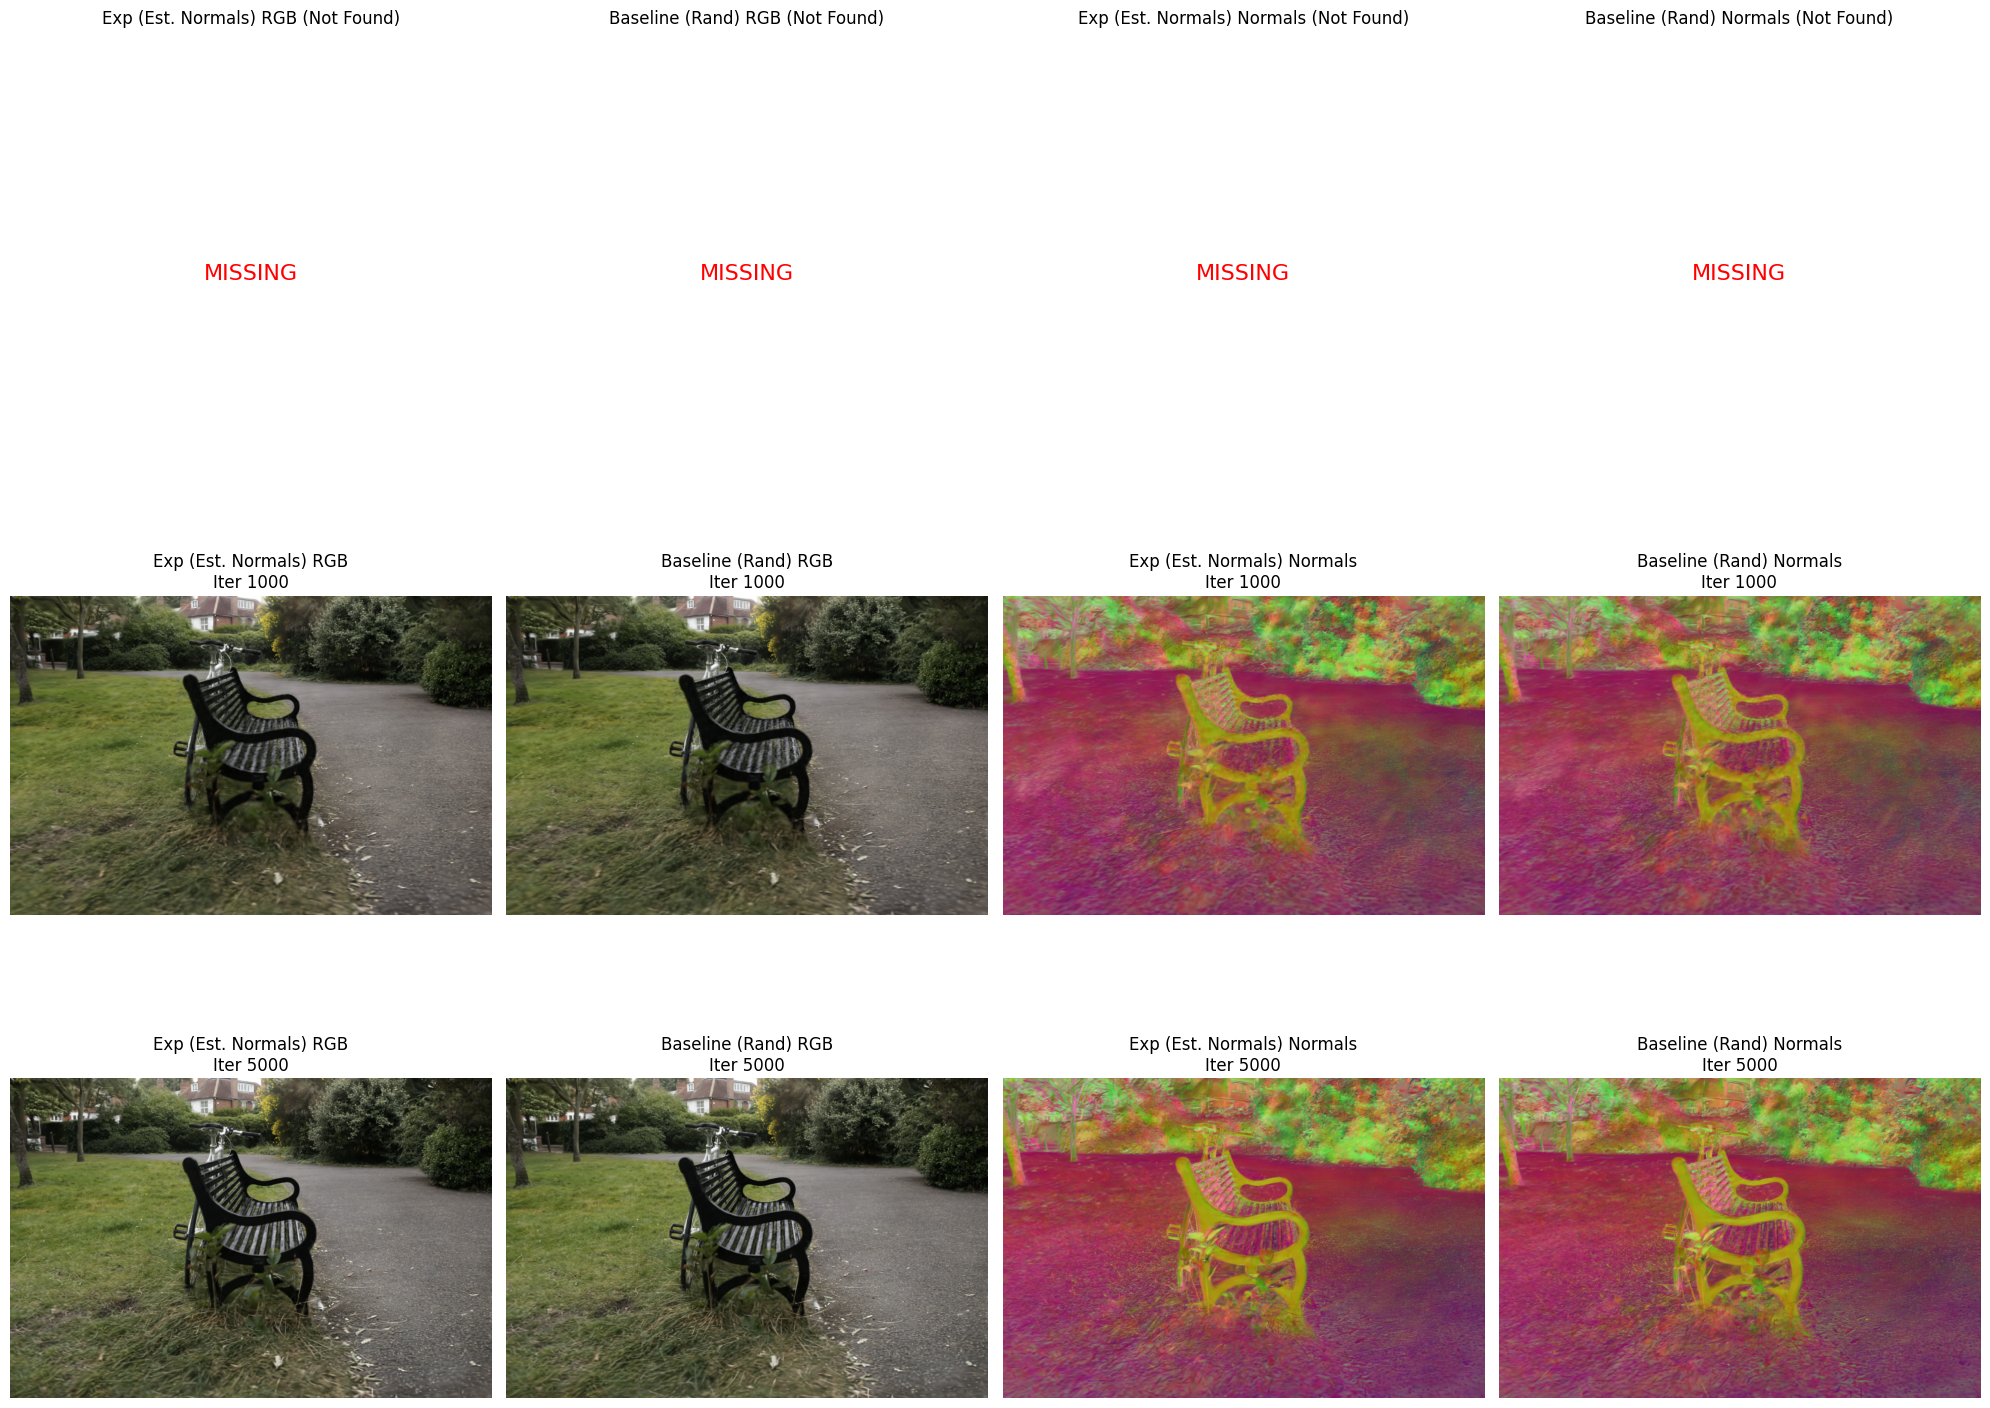

In [37]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np

def load_safe(path):
    """
    Safely loads an image. Returns None if missing.
    """
    if not os.path.exists(path):
        return None
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def compare_multiple_iterations(iterations, view_name):
    # --- CONFIGURATION ---
    root = "/content/drive/MyDrive/ADL4CV/Trained_Models"

    # Paths to your two experiments
    # Experiment A: The New Method (Estimated Normals)
    exp_A_path = os.path.join(root, "newnormals/2d-gaussian-splatting/output/experiment_estimated_normals/progress_renders")

    # Experiment B: The Baseline (Random Normals)
    exp_B_path = os.path.join(root, "baselinenormals/2d-gaussian-splatting/output/baseline_random_normals/progress_renders")

    # --- PLOTTING ---
    # Create a figure with 1 row per iteration
    # Each row has 4 columns: Exp RGB | Baseline RGB | Exp Normal | Baseline Normal
    rows = len(iterations)
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))

    # If only 1 iteration, axes is 1D array; make it 2D for consistent indexing
    if rows == 1:
        axes = np.array([axes])

    print(f"--- Generating Comparison for View: {view_name} ---")

    for i, iter_step in enumerate(iterations):
        # Construct folder paths for this specific iteration
        dir_A = os.path.join(exp_A_path, f"iteration_{iter_step}")
        dir_B = os.path.join(exp_B_path, f"iteration_{iter_step}")

        # Load Images
        rgb_A = load_safe(os.path.join(dir_A, f"{view_name}_rgb.png"))
        rgb_B = load_safe(os.path.join(dir_B, f"{view_name}_rgb.png"))
        norm_A = load_safe(os.path.join(dir_A, f"{view_name}_normal.png"))
        norm_B = load_safe(os.path.join(dir_B, f"{view_name}_normal.png"))

        # --- HELPER TO PLOT ---
        def plot_cell(ax, img, title_prefix):
            if img is not None:
                ax.imshow(img)
                ax.set_title(f"{title_prefix}\nIter {iter_step}")
            else:
                # Grey placeholder for missing data
                ax.text(0.5, 0.5, "MISSING", ha='center', va='center', color='red', fontsize=16)
                ax.set_facecolor("#eeeeee")
                ax.set_title(f"{title_prefix} (Not Found)")
            ax.axis('off')

        # Column 0: Exp RGB
        plot_cell(axes[i, 0], rgb_A, "Exp (Est. Normals) RGB")

        # Column 1: Baseline RGB
        plot_cell(axes[i, 1], rgb_B, "Baseline (Rand) RGB")

        # Column 2: Exp Normals
        plot_cell(axes[i, 2], norm_A, "Exp (Est. Normals) Normals")

        # Column 3: Baseline Normals
        plot_cell(axes[i, 3], norm_B, "Baseline (Rand) Normals")

    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Pass the list of iterations you want to see
# You can add 0 to this list if you ran the Zero-Shot update!
iterations_to_compare = [0, 1000, 5000]

# Make sure this view name exists in your folders!
view_to_check = "_DSC8768"

try:
    compare_multiple_iterations(iterations_to_compare, view_to_check)
except Exception as e:
    print(f"An error occurred: {e}")

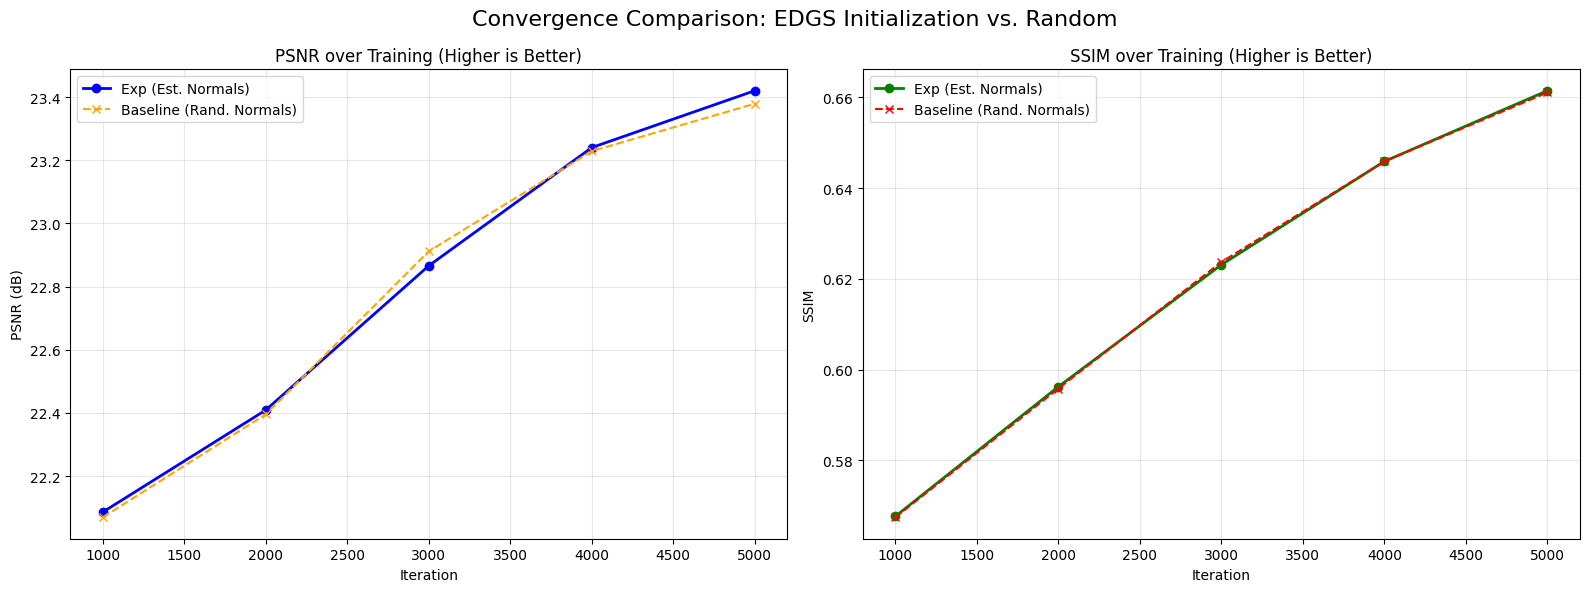

In [38]:
import os
import matplotlib.pyplot as plt
import re

def parse_metrics_log(log_path):
    """
    Parses the progress_log.txt file to extract iterations, PSNR, and SSIM.

    Expected format:
    Iter 1000: PSNR=22.4512, SSIM=0.7812
    """
    iterations = []
    psnrs = []
    ssims = []

    if not os.path.exists(log_path):
        print(f"[WARNING] Log file not found: {log_path}")
        return None

    with open(log_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue

            # Regex to extract numbers
            match = re.search(r'Iter (\d+): PSNR=([\d\.]+), SSIM=([\d\.]+)', line)
            if match:
                iterations.append(int(match.group(1)))
                psnrs.append(float(match.group(2)))
                ssims.append(float(match.group(3)))

    return {"iters": iterations, "psnr": psnrs, "ssim": ssims}

def plot_metrics_comparison():
    # --- CONFIGURATION ---
    root = "/content/drive/MyDrive/ADL4CV/Trained_Models"

    # Define paths to the log files
    # Experiment A: New Method
    exp_log = os.path.join(root, "newnormals/2d-gaussian-splatting/output/experiment_estimated_normals/progress_log.txt")

    # Experiment B: Baseline
    base_log = os.path.join(root, "baselinenormals/2d-gaussian-splatting/output/baseline_random_normals/progress_log.txt")

    # --- PARSING ---
    data_exp = parse_metrics_log(exp_log)
    data_base = parse_metrics_log(base_log)

    if data_exp is None or data_base is None:
        print("Could not load one or more log files. Check paths.")
        return

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. PSNR Plot
    axes[0].plot(data_exp['iters'], data_exp['psnr'], label='Exp (Est. Normals)', marker='o', linewidth=2, color='blue')
    axes[0].plot(data_base['iters'], data_base['psnr'], label='Baseline (Rand. Normals)', marker='x', linestyle='--', color='orange')
    axes[0].set_title("PSNR over Training (Higher is Better)")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("PSNR (dB)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. SSIM Plot
    axes[1].plot(data_exp['iters'], data_exp['ssim'], label='Exp (Est. Normals)', marker='o', linewidth=2, color='green')
    axes[1].plot(data_base['iters'], data_base['ssim'], label='Baseline (Rand. Normals)', marker='x', linestyle='--', color='red')
    axes[1].set_title("SSIM over Training (Higher is Better)")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("SSIM")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Convergence Comparison: EDGS Initialization vs. Random", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
try:
    plot_metrics_comparison()
except Exception as e:
    print(f"An error occurred: {e}")